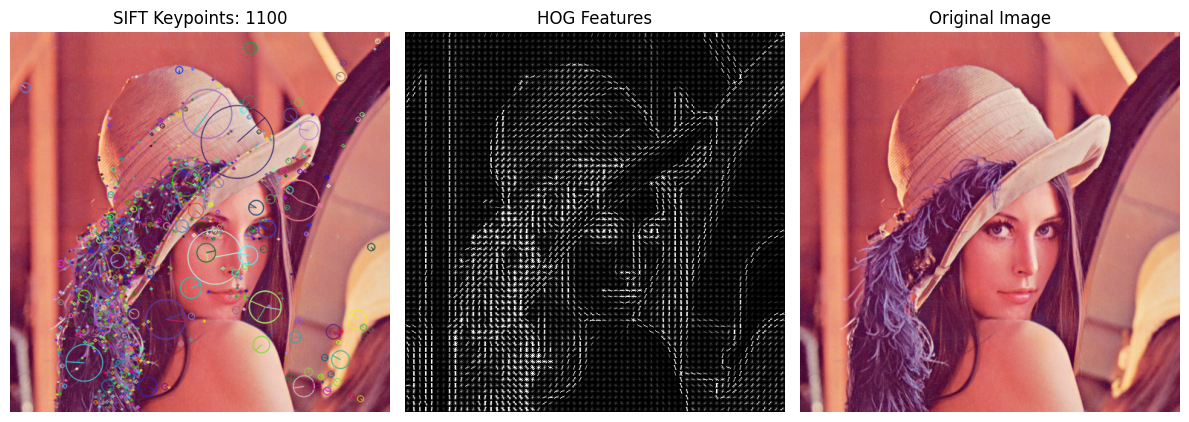

SIFT Descriptor shape: (1100, 128)
HOG Feature vector length: 142884


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure
import urllib.request

# -----------------------------
# Load Image from URL (WORKS in Colab)
# -----------------------------
# url = "https://upload.wikimedia.org/wikipedia/en/7/7d/Lenna_%28test_image%29.png"

image_file = '/content/sample_data/Lenna_test_image.png'
img = cv2.imread(image_file)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12,8))

# -----------------------------
# 1. SIFT
# -----------------------------
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(gray, None)

img_sift = cv2.drawKeypoints(
    img, keypoints, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB))
plt.title(f"SIFT Keypoints: {len(keypoints)}")
plt.axis('off')

# -----------------------------
# 2. HOG
# -----------------------------
features, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0,10))

plt.subplot(1,3,2)
plt.imshow(hog_image_rescaled, cmap='gray')
plt.title("HOG Features")
plt.axis('off')

# -----------------------------
# 3. Original Image
# -----------------------------
plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

plt.tight_layout()
plt.show()

# -----------------------------
# Feature Info
# -----------------------------
print("SIFT Descriptor shape:", descriptors.shape)
print("HOG Feature vector length:", len(features))
